In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.transforms import offset_copy

In [2]:
%run LittRuP__import_functions.ipynb

In [3]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()
DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"

In [4]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [5]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

In [6]:
# matrice des thèmes 0/1

matrix_themes = matrix_all_extended[theme_cols]

In [7]:
# indique que les identifiants sont toutes les colonnes situées avant les thèmes

to = matrix_all_extended.columns.get_loc("CutOff") + 1
ids_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("Works") + 0:to
]

In [8]:
# matrice des identifiants

matrix_ids = matrix_all_extended[ids_cols]

**Graphique de chronologie des oeuvres**

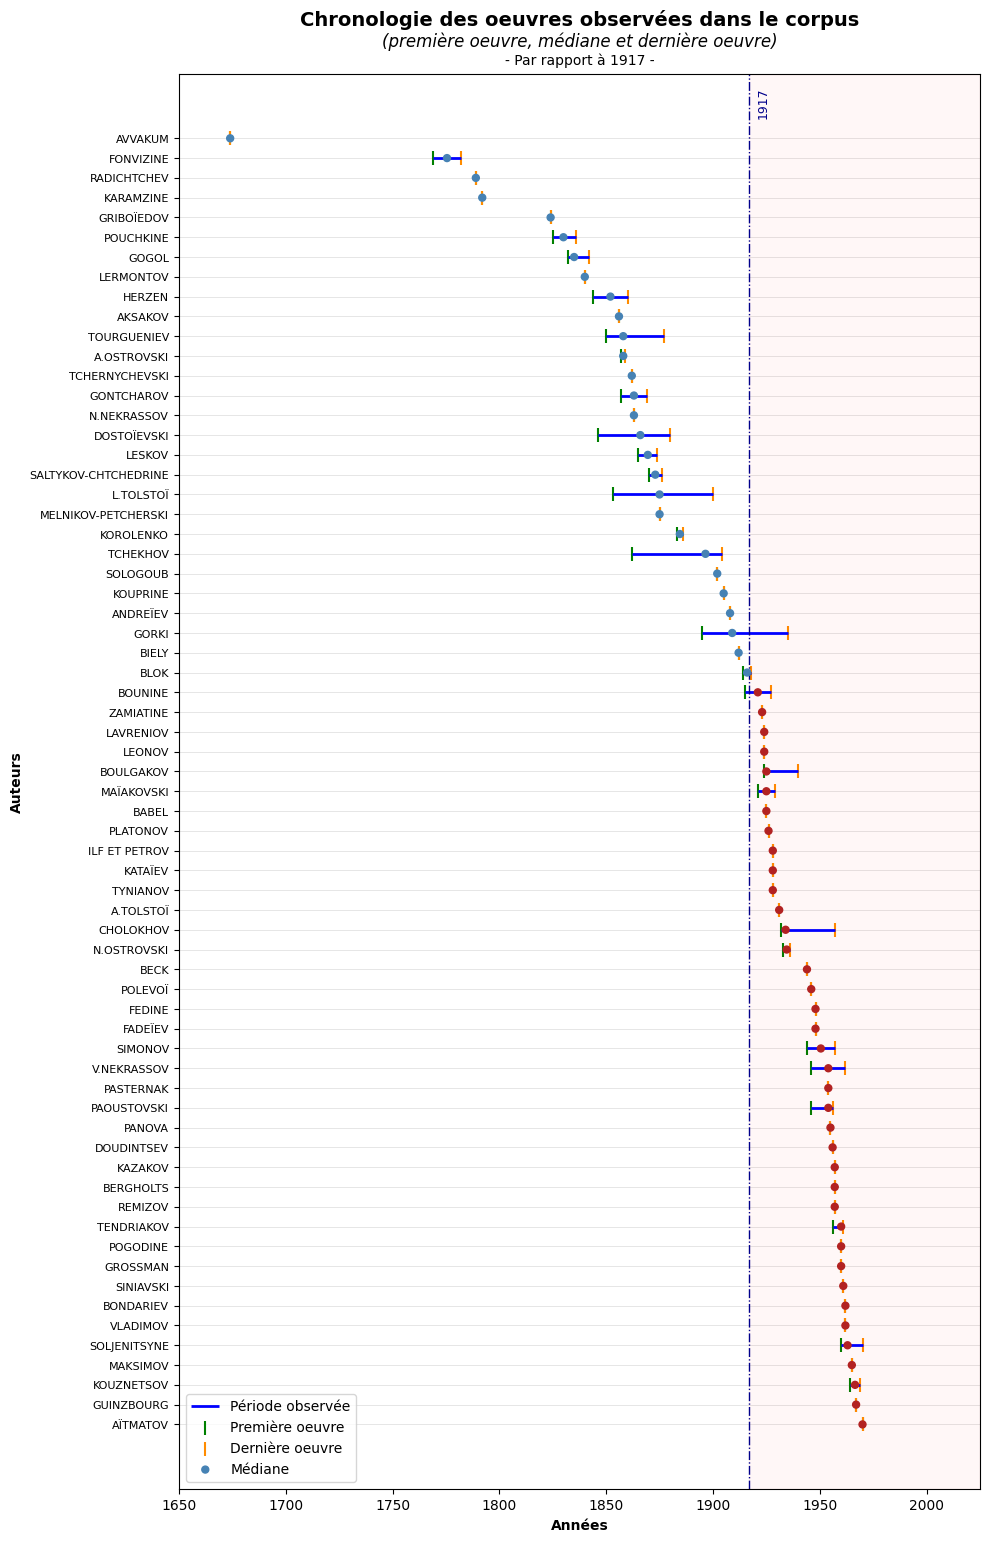

In [9]:
author_stats = (
    matrix_ids
    .groupby("Author")["Composed"]
    .agg(["min", "median", "max"])
    .sort_values("median")
)

fig, ax = plt.subplots(figsize=(10, 16))

ax.invert_yaxis()

ax.hlines(
    y=author_stats.index,
    xmin=author_stats["min"],
    xmax=author_stats["max"],
    color="blue",
    linestyle="-",
    linewidth=2,
    label="Période observée"
)

ax.scatter(
    author_stats["min"],
    author_stats.index,
    marker="|",
    color="green",
    s=100,
    linewidth=1.5,
    label="Première oeuvre"
)

ax.scatter(
    author_stats["max"],
    author_stats.index,
    marker="|",
    color="darkorange",    
    s=100,
    linewidth=1.5,
    label="Dernière oeuvre"
)

couleurs = np.where(
    author_stats["median"] <= 1917,
    "steelblue",
    "firebrick"
)

ax.scatter(
    author_stats["median"],
    author_stats.index,
    c=couleurs,
    s=25,
    zorder=3, # force la médiane au-dessus de la ligne
    label="Médiane"

)

ax.axvline(
    x=1917,
    color="darkblue",
    linestyle="dashdot",
    linewidth=1
)

trans = offset_copy(ax.transData, fig=fig, x=5, y=0, units='points')

ax.text(
    1917,
    -1,
    str(1917),
    transform=trans,
    rotation=90,
    va="bottom",
    fontsize=9,
    color="darkblue"
)

# coloration de la zone >1917
ax.axvspan(
    1917,
    2025,
    color="red",
    alpha=0.03
)

# lignes horizontales d'alignement des auteurs
ax.hlines(
    y=author_stats.index,
    xmin=1650,
    xmax=2025,
    color="lightgrey",
    linewidth=0.4,
    zorder=0
)

ax.set_xlim(1650, 2025)
ax.set_xlabel("Années", fontweight="bold")
ax.set_ylabel("Auteurs", fontweight="bold")
ax.tick_params(axis="y", labelsize=8)

ax.legend(loc="best")

fig.tight_layout(rect=[0, 0, 1, 0.93])


titres(
    fig,
    ax,
    t1="Chronologie des oeuvres observées dans le corpus", y1=35,
    t2="(première oeuvre, médiane et dernière oeuvre)", y2=20,
    t3="- Par rapport à 1917 -", y3=7
)

fig.savefig(
    IMG_DIR / "auteurs_chronologie_oeuvres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Graphique de chronologie des oeuvres (nouvelle périodisation)**
<1800,  [1800-1850,  [1800-1905[,  [1905-1917[,  [1917-1953[,  [1953-1991, >=1991

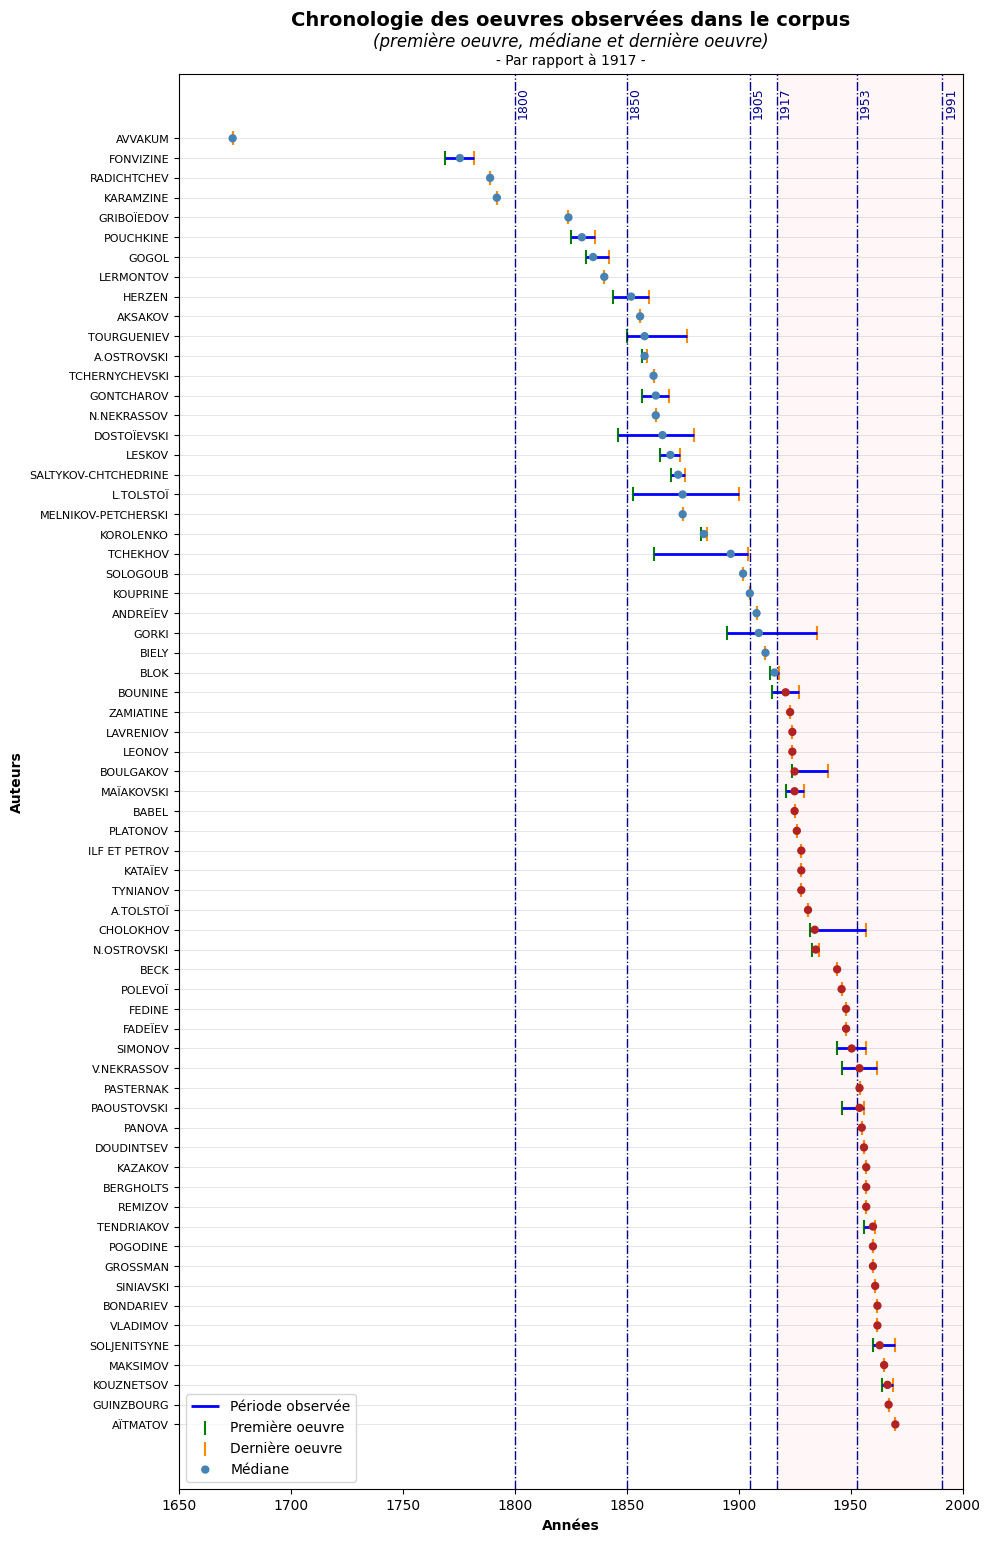

In [10]:
author_stats = (
    matrix_ids
    .groupby("Author")["Composed"]
    .agg(["min", "median", "max"])
    .sort_values("median")
)

fig, ax = plt.subplots(figsize=(10, 16))

ax.invert_yaxis()

ax.hlines(
    y=author_stats.index,
    xmin=author_stats["min"],
    xmax=author_stats["max"],
    color="blue",
    linestyle="-",
    linewidth=2,
    label="Période observée"
)

ax.scatter(
    author_stats["min"],
    author_stats.index,
    marker="|",
    color="green",
    s=100,
    linewidth=1.5,
    label="Première oeuvre"
)

ax.scatter(
    author_stats["max"],
    author_stats.index,
    marker="|",
    color="darkorange",    
    s=100,
    linewidth=1.5,
    label="Dernière oeuvre"
)

couleurs = np.where(
    author_stats["median"] <= 1917,
    "steelblue",
    "firebrick"
)

ax.scatter(
    author_stats["median"],
    author_stats.index,
    c=couleurs,
    s=25,
    zorder=3, # force la médiane au-dessus de la ligne
    label="Médiane"

)

trans = offset_copy(ax.transData, fig=fig, x=6, y=0, units='points')

for annee in [1800, 1850, 1905, 1917, 1953, 1991]:
    ax.axvline(
        x=annee,
        color="darkblue",
        linestyle="dashdot",
        linewidth=1
    )

    ax.text(
        annee,
        -1,
        str(annee),
        transform=trans,
        rotation=90,
        ha="center",
        va="bottom",
        fontsize=9,
        color="darkblue"
    )

# coloration de la zone >1917
ax.axvspan(
    1917,
    2000,
    color="red",
    alpha=0.03
)

# lignes horizontales d'alignement des auteurs
ax.hlines(
    y=author_stats.index,
    xmin=1650,
    xmax=2000,
    color="lightgrey",
    linewidth=0.4,
    zorder=0
)

ax.set_xlim(1650, 2000)
ax.set_xlabel("Années", fontweight="bold")
ax.set_ylabel("Auteurs", fontweight="bold")
ax.tick_params(axis="y", labelsize=8)

ax.legend(loc="best")

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(
    fig,
    ax,
    t1="Chronologie des oeuvres observées dans le corpus", y1=35,
    t2="(première oeuvre, médiane et dernière oeuvre)", y2=20,
    t3="- Par rapport à 1917 -", y3=7
)

fig.savefig(
    IMG_DIR / "auteurs_chronologie_oeuvres_périodisation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Nombre d'oeuvres par période (historique)**<br>
**[Calculé par rapport à la date de l'oeuvre]**<br>
**'[1917-1953[', '[1850-1905[', '[1800-1850[', '[1953-1991[', '<1800', '[1905-1917['**

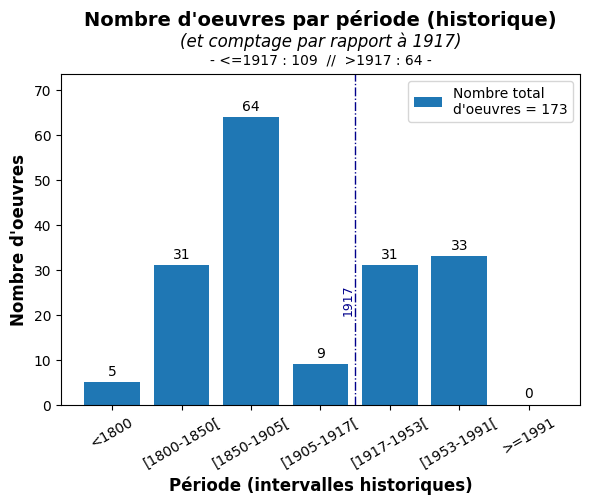

In [11]:
# pour oeuvres : ordre chronologique souhaité imposé

cutoff_order = [
    "<=1917",
    ">1917"
]

# pour oeuvres : compter les oeuvres par rapport à 1917

works_by_cutoff = (
    matrix_ids
    .groupby("CutOff")["Works"]
    .nunique()
    .reindex(cutoff_order, fill_value=0)
)

pred_17 = works_by_cutoff.tolist()[0]   # <=1917 : le résultat est 109
post_17 = works_by_cutoff.tolist()[1]   # >1917 : le résultat est 64

# pour oeuvre : ordre chronologique souhaité imposé

when_order = [
    "<1800",
    "[1800-1850[",
    "[1850-1905[",
    "[1905-1917[",
    "[1917-1953[",
    "[1953-1991[",
    ">=1991"
]

# pour oeuvres : compter les oeuvres par période

works_by_when = (
    matrix_ids
    .groupby("When")["Works"]
    .nunique()
    .reindex(when_order, fill_value=0)
)

N_works = works_by_when.values.sum().tolist()

# graphique

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(works_by_when.index, 
              works_by_when.values, 
              label = "Nombre total \n" + "d'oeuvres = " + f"{N_works:.0f}"
)

ax.bar_label(
    bars,
    labels=works_by_when.values,
    padding=3,
    fontsize=10
)

# Dans le graphique, les catégories : ["<1800", "[1800-1850[", "[1850-1905[", ...]
# sont traitées par Matplotlib comme des positions discrètes
# Autrement dit, en interne, Matplotlib les convertit automatiquement en : 0, 1, 2, 3, 4, 5
# la date 1917 appartient à l’intervalle : [1917-1953[ qui est à la position 4...
# il faut convertir 1917 en une position relative sur l’axe catégoriel !

# Dans ce cas (petit ajustement de 3 à 3.25...) :

x_1917 = 3.25 + (1917 - 1911) / (1935 - 1911) 
ax.axvline(x=x_1917, linestyle="dashdot", linewidth=1, color="darkblue")

ax.text(
    x_1917,
    20,
    "1917",
    rotation=90,
    va="bottom",
    ha="right",
    fontsize=9,
    color="darkblue"
)

ax.set_xlabel("Période (intervalles historiques)", fontweight="bold", fontsize=12)
ax.set_ylabel("Nombre d'oeuvres", fontweight="bold", fontsize=12)

ax.tick_params(axis="x", rotation=30)
ax.set_ylim(0, works_by_when.max() * 1.15)
plt.legend(loc="best")

fig.tight_layout(rect=[0,0,1,0.9])

titres(
    fig,
    ax,
    t1="Nombre d'oeuvres par période (historique)", y1=35,
    t2="(et comptage par rapport à 1917)", y2=20,
    t3=f"- <=1917 : {pred_17}  //  >1917 : {post_17} -", y3=7
)

fig.savefig(IMG_DIR / "oeuvres_périodes_historiques.png", dpi=300)

plt.show()

**Dates extrêmes des oeuvres du corpus**

In [12]:
matrix_ids["Composed"].min(), matrix_ids["Composed"].max()

(np.int64(1674), np.int64(1970))

**Nombre d'oeuvres par période**

In [13]:
works_by_when

When
<1800           5
[1800-1850[    31
[1850-1905[    64
[1905-1917[     9
[1917-1953[    31
[1953-1991[    33
>=1991          0
Name: Works, dtype: int64

**Liste des oeuvres contenant k thèmes**

In [14]:
# nombre de thèmes recherchés

k = 10

# Nombre de thèmes par oeuvre

n_themes = matrix_themes.sum(axis=1)

# liste des thèmes présents

themes_present = []

# parcourir toutes les lignes du DataFrame

for row_index, row in matrix_all_extended.iterrows():

    # liste des thèmes de l'oeuvre courante
    current_themes = []

    # parcourir tous les thèmes
    for theme in theme_cols:

        # si le thème est présent
        if row[theme] == 1:

            # ajouter le nom du thème
            current_themes.append(theme)

    # ajouter la liste au résultat final
    themes_present.append(current_themes)

# Construction du DataFrame final

works_k_themes = matrix_all_extended.loc[
    n_themes == k
].copy()

# ajouter les thèmes correspondants

works_k_themes["themes"] = [
    themes_present[i]
    for i in works_k_themes.index
]

# créer fichier propre
# Inplace = False: returns a copy where the removing is done.

works_k_themes_no_themes = works_k_themes.drop(theme_cols,  axis="columns", inplace = False)
works_k_themes_final = works_k_themes_no_themes.drop(["Birth", "Death", "Period", "When", "Name", "CutOff"],  axis="columns", inplace = False) 

In [15]:
works_k_themes_final

,Works,Author,Composed,themes
65,Guerre et Paix,L.TOLSTOÏ,1866,"[Amour, Dieu, Femme, Guerre, Héros, Mort, Nati..."


**Exporter la liste en image avec amélioration du style**

In [16]:

import dataframe_image as dfi

styled_df = (
    works_k_themes_final.style
    .hide(axis="index")
    .set_properties(subset=["themes"], **{
        "text-align": "left",
        "white-space": "pre-wrap"
    })
)

dfi.export(
    styled_df,
    IMG_DIR / "works_k_themes.png",
    table_conversion="matplotlib",
    dpi=300
)

**Oeuvres partageant certains thèmes**

In [17]:
# thèmes que l'on exige

themes_demandes = ["Argent", "Amour"]

# masque : lignes où tous les thèmes demandés valent 1
# <==> garder uniquement les lignes pour lesquelles 
#      tous les thèmes demandés sont présents

mask = matrix_all_extended[themes_demandes].eq(1).all(axis=1)

# sous-tableau avec seulement les œuvres concernées

works_selected = matrix_all_extended.loc[mask].copy()

# colonne contenant tous les thèmes présents dans chaque œuvre

themes_present = []

for index_ligne, row in matrix_all_extended.loc[mask].iterrows():
    liste_themes = row.index[row.eq(1)].tolist()
    themes_present.append(liste_themes)

# ajouter les thèmes correspondants

works_selected["thèmes"] = themes_present

# créer fichier propre
# Inplace = False: returns a copy where the removing is done.

works_selected_no_themes = works_selected.drop(theme_cols,  axis="columns", inplace = False)
works_selected_final = works_selected_no_themes.drop(["Birth", "Death", "Period", "When", "Name", "CutOff"],  axis="columns", inplace = False) 

In [216]:
works_selected_final

,Works,Author,Composed,thèmes
1,L'Adolescent,DOSTOÏEVSKI,1875,"[Amour, Apprentissage, Argent, Dieu, Femme, Oc..."
33,Dans les forêts,MELNIKOV-PETCHERSKI,1875,"[Amour, Argent, Paysans, Religion, Traditions]"
59,Les Frères Karamazov,DOSTOÏEVSKI,1880,"[Amour, Argent, Dieu, Mal, Pouvoir, Remords, S..."
71,Humiliés et Offensés,DOSTOÏEVSKI,1861,"[Amour, Argent, Femme, Humiliation, Mal, Misèr..."
74,L'Idiot,DOSTOÏEVSKI,1869,"[Amour, Argent, Délire-Folie, Dieu, Femme, Mar..."
81,Le Joueur,DOSTOÏEVSKI,1866,"[Amour, Argent, Femme, Jeu]"
112,L'Orage,A.OSTROVSKI,1859,"[Amour, Argent, Femme, Marchands, Rêve, Tradit..."
